<a href="https://colab.research.google.com/github/elias8080007/OIBSIP/blob/main/retail_sales_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis on Retail Sales Data

**Intern:** Elias Ibrahim Elias  
**Organization:** Oasis Infobyte  
**Track:** Data Analytics  
**Level:** Level 1  
**Task:** Exploratory Data Analysis on Retail Sales Data  

## Project Objective

The objective of this project is to analyse retail transaction data and identify important patterns in sales, customer behaviour, demographics, and product performance. The analysis will also provide actionable recommendations that can support business decision-making.

## Dataset

This project uses the **50K Global Retail Sales & Customer Ratings Data** dataset obtained from Kaggle.

**Dataset source:**  
https://www.kaggle.com/datasets/hanzalamushtaq/50k-global-retail-sales-and-customer-ratings-data

In [1]:
!pip install -q kagglehub # Kaggle’s official Python library for downloading public datasets programmatically

In [2]:
import os #csv file
import glob #csv file
import warnings

import numpy as np # library to perform numerical operations
import pandas as pd # is used to load and analyses tabular format data
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
dataset_handle = (
    "hanzalamushtaq/"
    "50k-global-retail-sales-and-customer-ratings-data"
)

dataset_path = kagglehub.dataset_download(dataset_handle)

print("Dataset downloaded successfully.") # for testing
print("Dataset location:", dataset_path)

100%|██████████| 1.16M/1.16M [00:00<00:00, 49.6MB/s]

Extracting files...
Dataset downloaded successfully.
Dataset location: /root/.cache/kagglehub/datasets/hanzalamushtaq/50k-global-retail-sales-and-customer-ratings-data/versions/1


In [4]:
csv_files = glob.glob(
    os.path.join(dataset_path, "**", "*.csv"),
    recursive=True
)

print("CSV files found:")

for index, file_path in enumerate(csv_files, start=1):
    print(f"{index}. {file_path}")

if not csv_files:
    raise FileNotFoundError("No CSV file was found in the downloaded dataset.")

CSV files found:
1. /root/.cache/kagglehub/datasets/hanzalamushtaq/50k-global-retail-sales-and-customer-ratings-data/versions/1/cleaned_global_ecommerce_data.csv


###### The datset was downloaded successfully and found

In [5]:
csv_path = csv_files[0]

df = pd.read_csv(csv_path) # to load the CSV

print("Dataset loaded successfully.")
print("Selected file:", os.path.basename(csv_path))
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head()) #display the first 5 rows records

Dataset loaded successfully.
Selected file: cleaned_global_ecommerce_data.csv
Number of rows: 50000
Number of columns: 15


,Transaction_ID,Date,Customer_ID,Customer_Age,Gender,Location,Product_Category,Product_Name,Unit_Price,Quantity,Discount_Applied,Total_Revenue,Payment_Method,Delivery_Time_Days,Customer_Rating
0,TXN1000,2023-01-01,CUST_4764,39,Male,Pakistan,Apparel,Cotton T-Shirt,89.50,3,0.04,257.76,PayPal,8,3.30
1,TXN1001,2023-01-01,CUST_20831,33,Male,Germany,Electronics,4K Smart TV,"1,129.50",3,0.05,"3,219.07",Credit Card,9,3.80
2,TXN1002,2023-01-01,CUST_15374,41,Non-binary,Germany,Home & Kitchen,Air Fryer,195.79,2,0.13,340.67,Credit Card,14,1.50
3,TXN1003,2023-01-01,CUST_17541,50,Non-binary,UAE,Electronics,Gaming Laptop,"1,153.43",1,0.10,"1,038.09",Bank Transfer,11,1.60
4,TXN1004,2023-01-01,CUST_14124,32,Male,UAE,Apparel,Formal Shirt,146.54,2,0.08,269.63,Credit Card,6,4.50


In [6]:
print("Column names:")

for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

print("\nData types and non-null counts:")
df.info() # It is very helpful and essential to know the exact column names

Column names:
1. Transaction_ID
2. Date
3. Customer_ID
4. Customer_Age
5. Gender
6. Location
7. Product_Category
8. Product_Name
9. Unit_Price
10. Quantity
11. Discount_Applied
12. Total_Revenue
13. Payment_Method
14. Delivery_Time_Days
15. Customer_Rating

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      50000 non-null  object 
 1   Date                50000 non-null  object 
 2   Customer_ID         50000 non-null  object 
 3   Customer_Age        50000 non-null  int64  
 4   Gender              50000 non-null  object 
 5   Location            50000 non-null  object 
 6   Product_Category    50000 non-null  object 
 7   Product_Name        50000 non-null  object 
 8   Unit_Price          50000 non-null  float64
 9   Quantity            50000 non-null  int64  
 10  Discount

## 1. Data Quality Assessment and Preparation

# Before performing the  analysis, we neeed first to check if the dataset is having  missing values, duplicate records, incorrect data types, inconsistent categories, and unrealistic numerical values.

In [7]:
df_original = df.copy() # took a copy of the original one, to prevent making error while cleaning

print("A copy of the original dataset was created.")

A copy of the original dataset was created.


In [8]:
quality_report = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Values": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2),
    "Unique_Values": df.nunique()
})

quality_report.index.name = "Column"

display(quality_report)

duplicate_count = df.duplicated().sum()

print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Duplicate rows: {duplicate_count:,}") # Must see if there anything missing or incorrect

,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
Column,,,,
Transaction_ID,object,0,0.00,50000
Date,object,0,0.00,1248
Customer_ID,object,0,0.00,18352
Customer_Age,int64,0,0.00,53
Gender,object,0,0.00,3
Location,object,0,0.00,6
Product_Category,object,0,0.00,5
Product_Name,object,0,0.00,25
Unit_Price,float64,0,0.00,30218


Number of rows: 50,000
Number of columns: 15
Duplicate rows: 0


In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce") #convert the text into dates

invalid_dates = df["Date"].isnull().sum()

print("Date column type:", df["Date"].dtype)
print("Invalid dates:", invalid_dates)
print("Earliest transaction:", df["Date"].min())
print("Latest transaction:", df["Date"].max())

Date column type: datetime64[ns]
Invalid dates: 0
Earliest transaction: 2023-01-01 00:00:00
Latest transaction: 2026-06-01 00:00:00


In [10]:
numeric_columns = [
    "Customer_Age",
    "Unit_Price",
    "Quantity",
    "Discount_Applied",
    "Total_Revenue",
    "Delivery_Time_Days",
    "Customer_Rating"
]

numeric_range_summary = (
    df[numeric_columns]
    .agg(["min", "max", "mean", "median"])
    .transpose()
    .round(2)
)

display(numeric_range_summary)

,min,max,mean,median
Column,,,,
Customer_Age,18.00,70.00,34.70,35.00
Unit_Price,5.00,"1,499.99",300.43,123.04
Quantity,1.00,5.00,2.48,2.00
Discount_Applied,0.00,0.30,0.12,0.11
Total_Revenue,4.67,"6,373.34",642.53,244.28
Delivery_Time_Days,1.00,15.00,7.99,8.00
Customer_Rating,1.00,5.00,3.33,3.50


In [11]:
validation_checks = pd.Series({
    "Non-positive customer ages": (df["Customer_Age"] <= 0).sum(),
    "Non-positive unit prices": (df["Unit_Price"] <= 0).sum(),
    "Non-positive quantities": (df["Quantity"] <= 0).sum(),
    "Negative discounts": (df["Discount_Applied"] < 0).sum(),
    "Negative total revenue": (df["Total_Revenue"] < 0).sum(),
    "Negative delivery times": (df["Delivery_Time_Days"] < 0).sum(),
    "Ratings outside 1–5": (
        (df["Customer_Rating"] < 1) |
        (df["Customer_Rating"] > 5)
    ).sum()
}, name="Potentially_Invalid_Rows")

display(validation_checks.to_frame())

,Potentially_Invalid_Rows
Non-positive customer ages,0
Non-positive unit prices,0
Non-positive quantities,0
Negative discounts,0
Negative total revenue,0
Negative delivery times,0
Ratings outside 1–5,0


In [12]:
categorical_columns = [ #inspect the gender category
    "Gender",
    "Product_Category",
    "Payment_Method"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- Gender ---
Gender
Female        22753
Male          22397
Non-binary     4850
Name: count, dtype: int64

--- Product_Category ---
Product_Category
Electronics       15018
Apparel           12299
Home & Kitchen     8297
Sports             7368
Beauty             7018
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
Credit Card      24950
PayPal           15052
Bank Transfer     7530
Crypto            2468
Name: count, dtype: int64


In [13]:
location_summary = ( # same for the inspaction of locations
    df["Location"]
    .value_counts()
    .head(10)
    .rename_axis("Location")
    .reset_index(name="Transaction_Count")
)

display(location_summary)


,Location,Transaction_Count
0,Pakistan,8377
1,Germany,8360
2,USA,8348
3,UK,8345
4,UAE,8289
5,India,8281


## 2. Descriptive Statistics

#Descriptive statistics are calculated for every meaningful numerical variable. The mean, median, mode, and standard deviation help describe the central tendency and variability of customer, transaction, and sales measurements.

#Additional measures—including quartiles, range, interquartile range, and coefficient of variation—are included to provide a more complete understanding of the distributions.

In [14]:
numeric_columns = [ #selecting the numerical columns instead of using every numeric filed
    "Customer_Age",
    "Unit_Price",
    "Quantity",
    "Discount_Applied",
    "Total_Revenue",
    "Delivery_Time_Days",
    "Customer_Rating"
] # like Transaction_ID and the customer_ID are identifiers so calculating their means have no meaning

missing_columns = [
    column for column in numeric_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"The following required columns are missing: {missing_columns}"
    )

print("Numerical columns selected for analysis:")

for column in numeric_columns:
    print(f"- {column}")

Numerical columns selected for analysis:
- Customer_Age
- Unit_Price
- Quantity
- Discount_Applied
- Total_Revenue
- Delivery_Time_Days
- Customer_Rating


In [15]:
descriptive_statistics = pd.DataFrame(
    index=numeric_columns
)

descriptive_statistics["Count"] = df[numeric_columns].count()
descriptive_statistics["Mean"] = df[numeric_columns].mean()
descriptive_statistics["Median"] = df[numeric_columns].median()

descriptive_statistics["Mode"] = df[numeric_columns].apply(
    lambda column: (
        column.mode().iloc[0]
        if not column.mode().empty
        else np.nan
    )
)

descriptive_statistics["Standard_Deviation"] = (
    df[numeric_columns].std(ddof=1)
)

descriptive_statistics["Minimum"] = df[numeric_columns].min()
descriptive_statistics["Q1"] = df[numeric_columns].quantile(0.25)
descriptive_statistics["Q3"] = df[numeric_columns].quantile(0.75)
descriptive_statistics["Maximum"] = df[numeric_columns].max()

descriptive_statistics["Range"] = (
    descriptive_statistics["Maximum"]
    - descriptive_statistics["Minimum"]
)

descriptive_statistics["IQR"] = (
    descriptive_statistics["Q3"]
    - descriptive_statistics["Q1"]
)

descriptive_statistics["CV_Percentage"] = (
    descriptive_statistics["Standard_Deviation"]
    / descriptive_statistics["Mean"].abs()
    * 100
)

descriptive_statistics = descriptive_statistics.round(2)

display(descriptive_statistics)

,Count,Mean,Median,Mode,Standard_Deviation,Minimum,Q1,Q3,Maximum,Range,IQR,CV_Percentage
Customer_Age,50000,34.70,35.00,18.00,9.57,18.00,28.00,41.00,70.00,52.00,13.00,27.57
Unit_Price,50000,300.43,123.04,56.06,389.48,5.00,60.23,296.78,"1,499.99","1,494.99",236.55,129.64
Quantity,50000,2.48,2.00,3.00,1.15,1.00,2.00,3.00,5.00,4.00,1.00,46.37
Discount_Applied,50000,0.12,0.11,0.02,0.08,0.00,0.06,0.18,0.30,0.30,0.12,66.85
Total_Revenue,50000,642.53,244.28,41.87,946.09,4.67,107.98,665.78,"6,373.34","6,368.67",557.80,147.25
Delivery_Time_Days,50000,7.99,8.00,13.00,4.32,1.00,4.00,12.00,15.00,14.00,8.00,54.05
Customer_Rating,50000,3.33,3.50,3.50,1.10,1.00,2.50,4.20,5.00,4.00,1.70,32.92


In [16]:
required_statistics = descriptive_statistics[
    [
        "Mean",
        "Median",
        "Mode",
        "Standard_Deviation"
    ]
].copy()

required_statistics.columns = [
    "Mean",
    "Median",
    "Mode",
    "Standard Deviation"
]

display(required_statistics)

,Mean,Median,Mode,Standard Deviation
Customer_Age,34.70,35.00,18.00,9.57
Unit_Price,300.43,123.04,56.06,389.48
Quantity,2.48,2.00,3.00,1.15
Discount_Applied,0.12,0.11,0.02,0.08
Total_Revenue,642.53,244.28,41.87,946.09
Delivery_Time_Days,7.99,8.00,13.00,4.32
Customer_Rating,3.33,3.50,3.50,1.10


In [17]:
variability_ranking = (
    descriptive_statistics["CV_Percentage"]
    .sort_values(ascending=False)
    .rename("CV_Percentage")
    .to_frame()
)

display(variability_ranking)

,CV_Percentage
Total_Revenue,147.25
Unit_Price,129.64
Discount_Applied,66.85
Delivery_Time_Days,54.05
Quantity,46.37
Customer_Rating,32.92
Customer_Age,27.57


## 3. Monthly and Quarterly Sales Trends

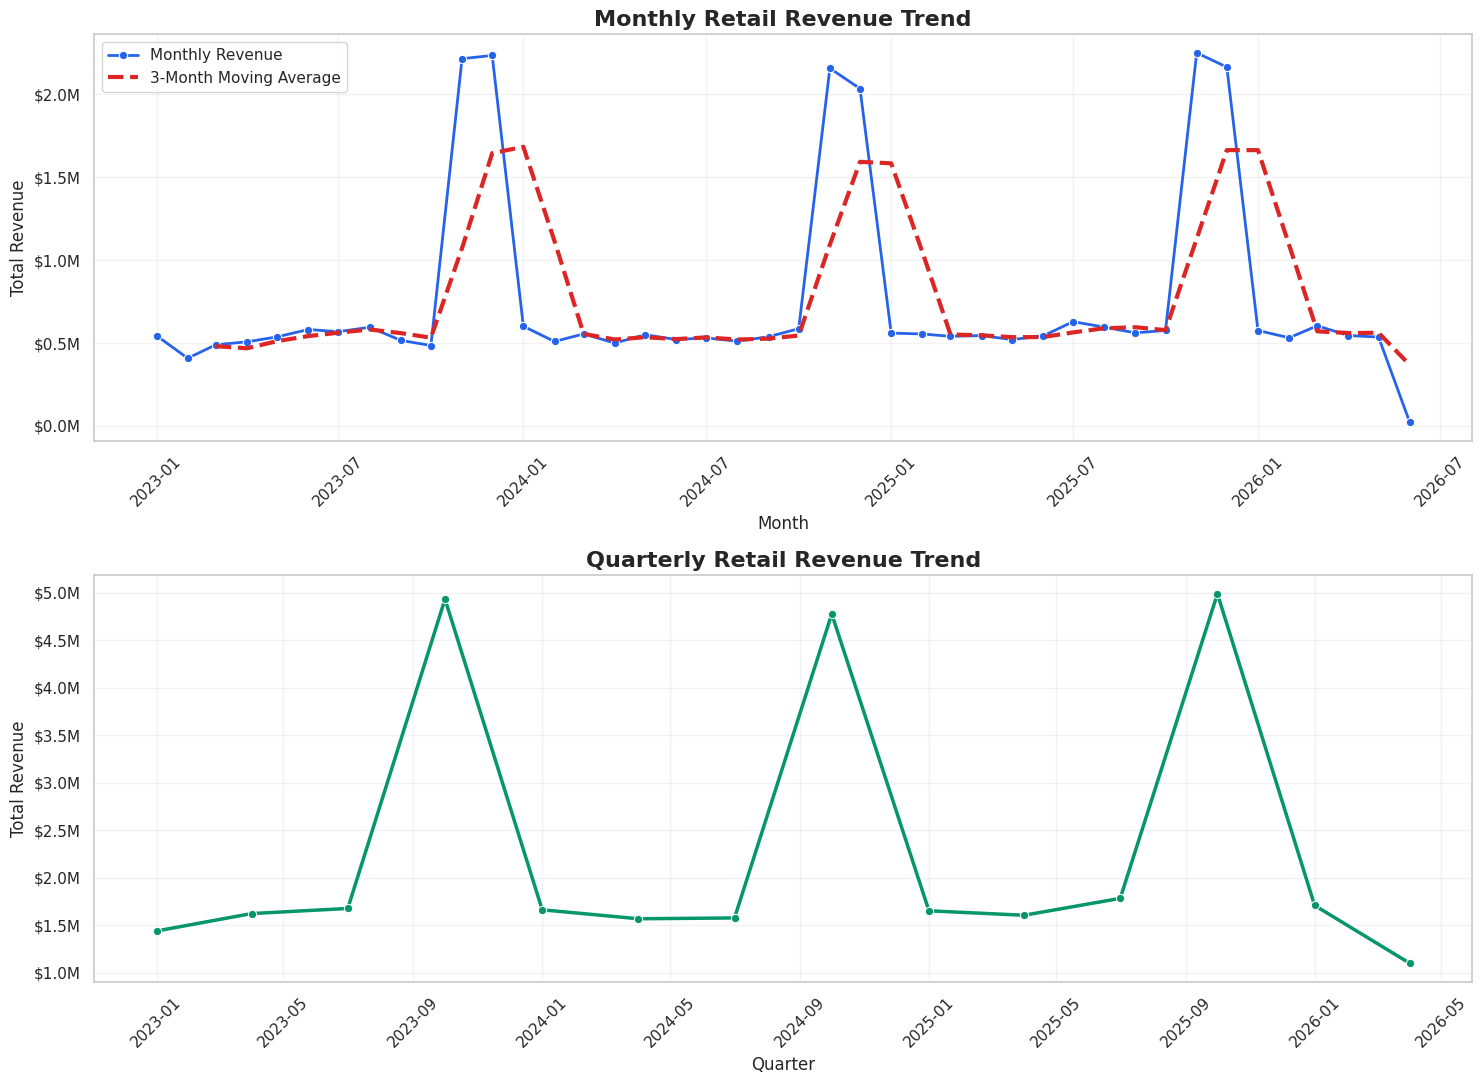

Highest-revenue month: November 2025 - $2,250,514.43
Lowest-revenue month: June 2026 - $21,608.65
Highest-revenue quarter: 2025Q4 - $4,990,906.58
Lowest-revenue quarter: 2026Q2 - $1,102,408.84


In [18]:
from matplotlib.ticker import FuncFormatter

# Aggregate total revenue by month
monthly_sales = (
    df.resample("MS", on="Date")["Total_Revenue"]
    .sum()
    .reset_index(name="Monthly_Revenue")
)

# Calculate a three-month moving average
monthly_sales["Three_Month_Moving_Average"] = (
    monthly_sales["Monthly_Revenue"]
    .rolling(window=3)
    .mean()
)

# Aggregate total revenue by quarter
quarterly_sales = (
    df.resample("QS", on="Date")["Total_Revenue"]
    .sum()
    .reset_index(name="Quarterly_Revenue")
)

# Format large monetary values in millions
millions_formatter = FuncFormatter(
    lambda value, position: f"${value / 1_000_000:.1f}M"
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 11)
)

# Monthly revenue chart
sns.lineplot(
    data=monthly_sales,
    x="Date",
    y="Monthly_Revenue",
    marker="o",
    linewidth=2,
    color="#2563EB",
    label="Monthly Revenue",
    ax=axes[0]
)

sns.lineplot(
    data=monthly_sales,
    x="Date",
    y="Three_Month_Moving_Average",
    linewidth=3,
    linestyle="--",
    color="#DC2626",
    label="3-Month Moving Average",
    ax=axes[0]
)

axes[0].set_title(
    "Monthly Retail Revenue Trend",
    fontsize=16,
    fontweight="bold"
)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Revenue")
axes[0].yaxis.set_major_formatter(millions_formatter)
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[0].grid(alpha=0.25)

# Quarterly revenue chart
sns.lineplot(
    data=quarterly_sales,
    x="Date",
    y="Quarterly_Revenue",
    marker="o",
    linewidth=2.5,
    color="#059669",
    ax=axes[1]
)

axes[1].set_title(
    "Quarterly Retail Revenue Trend",
    fontsize=16,
    fontweight="bold"
)
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Total Revenue")
axes[1].yaxis.set_major_formatter(millions_formatter)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.25)

plt.tight_layout()

# Save a high-quality image for GitHub and the demonstration
os.makedirs("/content/outputs", exist_ok=True)

plt.savefig(
    "/content/outputs/monthly_quarterly_sales_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Identify the highest and lowest periods
peak_month = monthly_sales.loc[
    monthly_sales["Monthly_Revenue"].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales["Monthly_Revenue"].idxmin()
]

peak_quarter = quarterly_sales.loc[
    quarterly_sales["Quarterly_Revenue"].idxmax()
]

lowest_quarter = quarterly_sales.loc[
    quarterly_sales["Quarterly_Revenue"].idxmin()
]

print(
    "Highest-revenue month:",
    peak_month["Date"].strftime("%B %Y"),
    f"- ${peak_month['Monthly_Revenue']:,.2f}"
)

print(
    "Lowest-revenue month:",
    lowest_month["Date"].strftime("%B %Y"),
    f"- ${lowest_month['Monthly_Revenue']:,.2f}"
)

print(
    "Highest-revenue quarter:",
    str(peak_quarter["Date"].to_period("Q")),
    f"- ${peak_quarter['Quarterly_Revenue']:,.2f}"
)

print(
    "Lowest-revenue quarter:",
    str(lowest_quarter["Date"].to_period("Q")),
    f"- ${lowest_quarter['Quarterly_Revenue']:,.2f}"
)

### Observation

Retail revenue shows a clear seasonal pattern, with major increases near the end of each year. November 2025 recorded the highest monthly revenue at **\$2,250,514.43**, while **2025 Q4** was the strongest quarter at **\$4,990,906.58**. Similar fourth-quarter peaks appear in 2023 and 2024, indicating consistently stronger year-end demand.

June 2026 had the lowest recorded monthly revenue at **\$21,608.65**, while **2026 Q2** had the lowest quarterly revenue at **\$1,102,408.84**. However, these unusually low values likely represent an incomplete final month and quarter, so they should not be interpreted as a confirmed sales decline. The business should prepare inventory and marketing campaigns before the recurring fourth-quarter sales peak.

## 4. Customer Demographics Analysis

#Customer demographics are analysed using unique customer records. Customers are divided into meaningful age groups, and gender distribution is examined to understand the composition of the customer base.

Number of unique customers: 18,352

Age-group distribution:


,Age_Group,Customer_Count,Percentage
0,18–24,2882,15.70
1,25–34,6263,34.13
2,35–44,6322,34.45
3,45–54,2486,13.55
4,55–64,380,2.07
5,65+,19,0.10



Gender distribution:


,Gender,Customer_Count,Percentage
0,Female,8331,45.40
1,Male,8262,45.02
2,Non-binary,1759,9.58


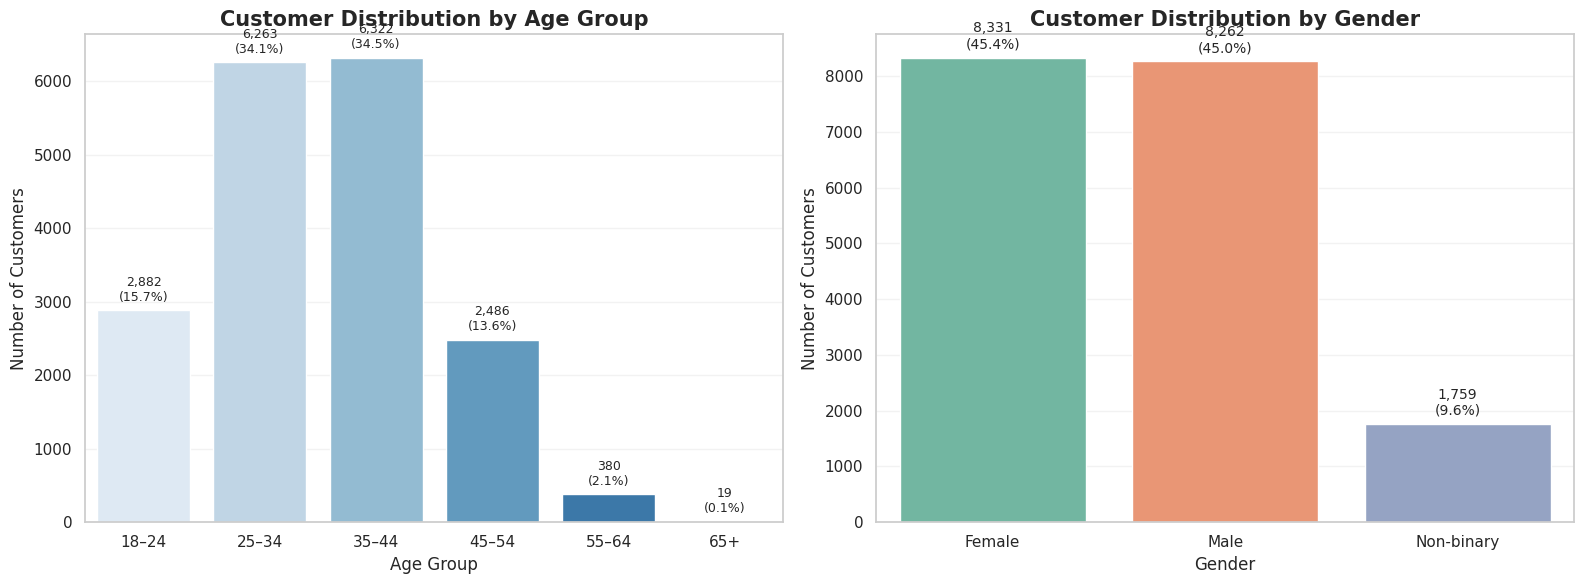

Largest age group: 35–44 (34.45%)
Largest gender group: Female (45.40%)


In [19]:
# Keep one demographic record for every unique customer
customer_demographics = (
    df[
        [
            "Customer_ID",
            "Customer_Age",
            "Gender"
        ]
    ]
    .drop_duplicates(subset="Customer_ID")
    .copy()
)

# Define clear customer age groups
age_bins = [
    17,
    24,
    34,
    44,
    54,
    64,
    np.inf
]

age_labels = [
    "18–24",
    "25–34",
    "35–44",
    "45–54",
    "55–64",
    "65+"
]

customer_demographics["Age_Group"] = pd.cut(
    customer_demographics["Customer_Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# Calculate customer count and percentage by age group
age_distribution = (
    customer_demographics["Age_Group"]
    .value_counts()
    .sort_index()
    .rename_axis("Age_Group")
    .reset_index(name="Customer_Count")
)

age_distribution["Percentage"] = (
    age_distribution["Customer_Count"]
    / age_distribution["Customer_Count"].sum()
    * 100
).round(2)

# Calculate customer count and percentage by gender
gender_distribution = (
    customer_demographics["Gender"]
    .value_counts()
    .rename_axis("Gender")
    .reset_index(name="Customer_Count")
)

gender_distribution["Percentage"] = (
    gender_distribution["Customer_Count"]
    / gender_distribution["Customer_Count"].sum()
    * 100
).round(2)

print(
    f"Number of unique customers: "
    f"{customer_demographics['Customer_ID'].nunique():,}"
)

print("\nAge-group distribution:")
display(age_distribution)

print("\nGender distribution:")
display(gender_distribution)

# Create the demographic visualizations
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# Age-group chart
sns.barplot(
    data=age_distribution,
    x="Age_Group",
    y="Customer_Count",
    hue="Age_Group",
    palette="Blues",
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Customer Distribution by Age Group",
    fontsize=15,
    fontweight="bold"
)
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Customers")
axes[0].grid(axis="y", alpha=0.25)

age_offset = age_distribution["Customer_Count"].max() * 0.02

for position, row in age_distribution.iterrows():
    axes[0].text(
        position,
        row["Customer_Count"] + age_offset,
        f"{row['Customer_Count']:,}\n({row['Percentage']:.1f}%)",
        ha="center",
        fontsize=9
    )

# Gender chart
sns.barplot(
    data=gender_distribution,
    x="Gender",
    y="Customer_Count",
    hue="Gender",
    palette="Set2",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Customer Distribution by Gender",
    fontsize=15,
    fontweight="bold"
)
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Number of Customers")
axes[1].grid(axis="y", alpha=0.25)

gender_offset = gender_distribution["Customer_Count"].max() * 0.02

for position, row in gender_distribution.iterrows():
    axes[1].text(
        position,
        row["Customer_Count"] + gender_offset,
        f"{row['Customer_Count']:,}\n({row['Percentage']:.1f}%)",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

# Save the visualizations for GitHub
os.makedirs("/content/outputs", exist_ok=True)

plt.savefig(
    "/content/outputs/customer_demographics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Print the most important findings
largest_age_group = age_distribution.loc[
    age_distribution["Customer_Count"].idxmax()
]

largest_gender_group = gender_distribution.loc[
    gender_distribution["Customer_Count"].idxmax()
]

print(
    "Largest age group:",
    largest_age_group["Age_Group"],
    f"({largest_age_group['Percentage']:.2f}%)"
)

print(
    "Largest gender group:",
    largest_gender_group["Gender"],
    f"({largest_gender_group['Percentage']:.2f}%)"
)

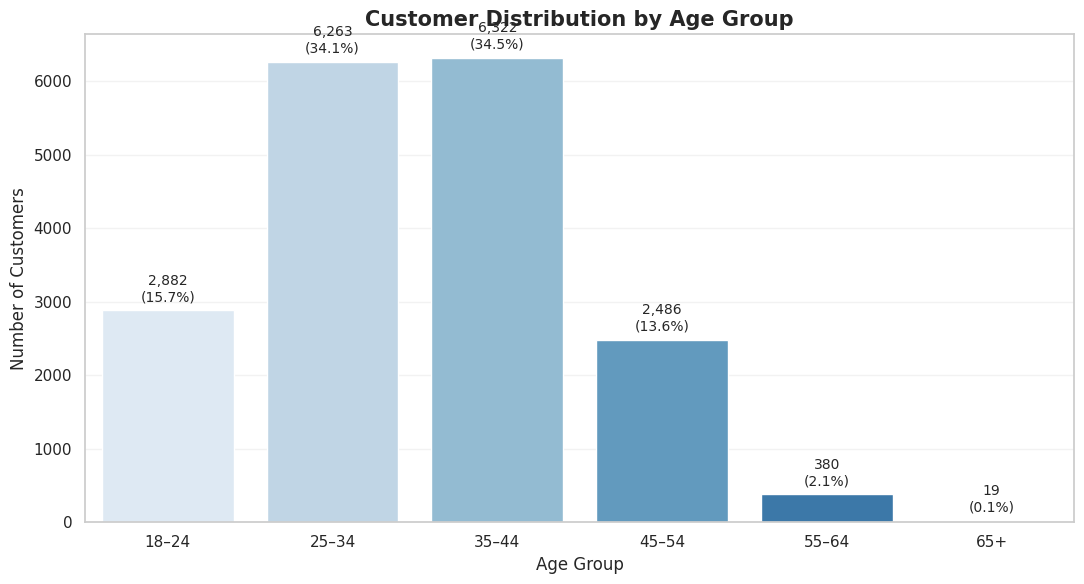

In [20]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=age_distribution,
    x="Age_Group",
    y="Customer_Count",
    hue="Age_Group",
    palette="Blues",
    legend=False
)

plt.title(
    "Customer Distribution by Age Group",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.25)

age_offset = age_distribution["Customer_Count"].max() * 0.02

for position, row in age_distribution.iterrows():
    ax.text(
        position,
        row["Customer_Count"] + age_offset,
        f"{row['Customer_Count']:,}\n({row['Percentage']:.1f}%)",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "/content/outputs/customer_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Customers aged **35–44** formed the largest group, with **6,325 customers (34.5%)**, closely followed by the **25–34** group, with **6,263 customers (34.1%)**. Together, customers aged **25–44** represented **68.6%** of the unique customer base, making them the retailer’s primary audience.

Customers aged **55 and above** represented only **2.2%** of customers. Marketing campaigns and product recommendations should therefore prioritize the 25–44 segment, while further research could explore whether specialized products or promotions might improve engagement among older customers.

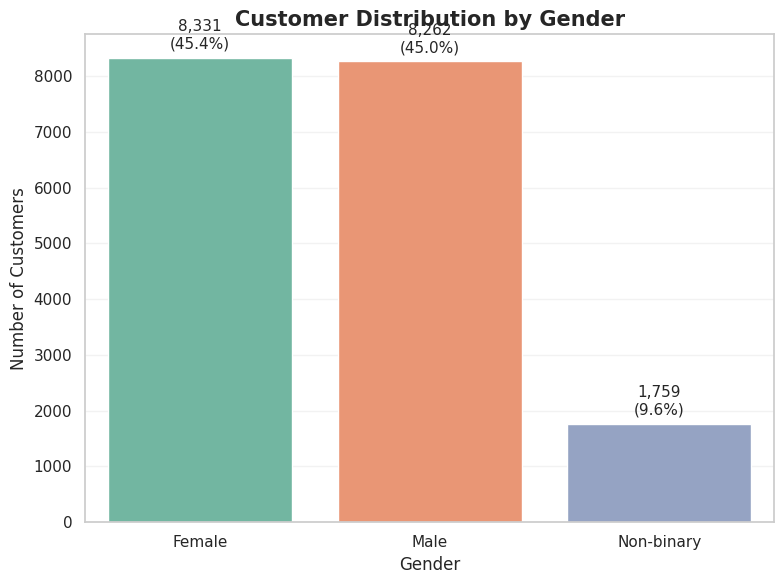

In [21]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=gender_distribution,
    x="Gender",
    y="Customer_Count",
    hue="Gender",
    palette="Set2",
    legend=False
)

plt.title(
    "Customer Distribution by Gender",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.grid(axis="y", alpha=0.25)

gender_offset = gender_distribution["Customer_Count"].max() * 0.02

for position, row in gender_distribution.iterrows():
    ax.text(
        position,
        row["Customer_Count"] + gender_offset,
        f"{row['Customer_Count']:,}\n({row['Percentage']:.1f}%)",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "/content/outputs/customer_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

#The customer base is almost evenly distributed between **female customers (45.4%)** and **male customers (45.0%)**, with a difference of only 69 customers. Non-binary customers represent the remaining **9.6%**.

#This balanced distribution suggests that the retailer should use inclusive marketing strategies rather than focusing primarily on one gender. Further analysis of purchasing behaviour by gender would be needed before designing segment-specific product recommendations or promotions.

## 5. Product Performance Analysis

#Product performance is evaluated using total units sold and generated revenue. The ten best-selling products are ranked by quantity, while product categories are compared using total revenue.

In [22]:
# Summarise performance for every product
product_performance = (
    df.groupby("Product_Name", as_index=False)
    .agg(
        Units_Sold=("Quantity", "sum"),
        Total_Revenue=("Total_Revenue", "sum"),
        Transaction_Count=("Transaction_ID", "nunique")
    )
    .sort_values("Units_Sold", ascending=False)
)

# Select the ten products with the most units sold
top_10_products = product_performance.head(10).copy()

# Summarise revenue and sales by product category
category_performance = (
    df.groupby("Product_Category", as_index=False)
    .agg(
        Total_Revenue=("Total_Revenue", "sum"),
        Units_Sold=("Quantity", "sum"),
        Transaction_Count=("Transaction_ID", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
)

print("Top 10 best-selling products:")
display(top_10_products)

print("\nRevenue by product category:")
display(category_performance)

Top 10 best-selling products:


,Product_Name,Units_Sold,Total_Revenue,Transaction_Count
23,Wireless Noise-Canceling Headphones,7640,"4,993,167.05",3042
0,4K Smart TV,7554,"5,104,079.79",3027
18,Smartphone 128GB,7552,"5,105,295.24",3032
11,Gaming Laptop,7344,"4,824,765.95",2973
19,Smartwatch,7288,"4,797,239.68",2944
22,Winter Jacket,6218,"422,950.68",2482
17,Running Shoes,6157,"427,043.35",2476
10,Formal Shirt,6092,"421,943.55",2484
4,Cotton T-Shirt,6071,"415,410.00",2441
6,Denim Jeans,6004,"408,863.07",2416



Revenue by product category:


,Product_Category,Total_Revenue,Units_Sold,Transaction_Count
2,Electronics,"24,824,547.71",37378,15018
3,Home & Kitchen,"2,905,955.24",20611,8297
0,Apparel,"2,096,210.65",30542,12299
4,Sports,"1,663,166.49",18311,7368
1,Beauty,"636,456.35",17311,7018


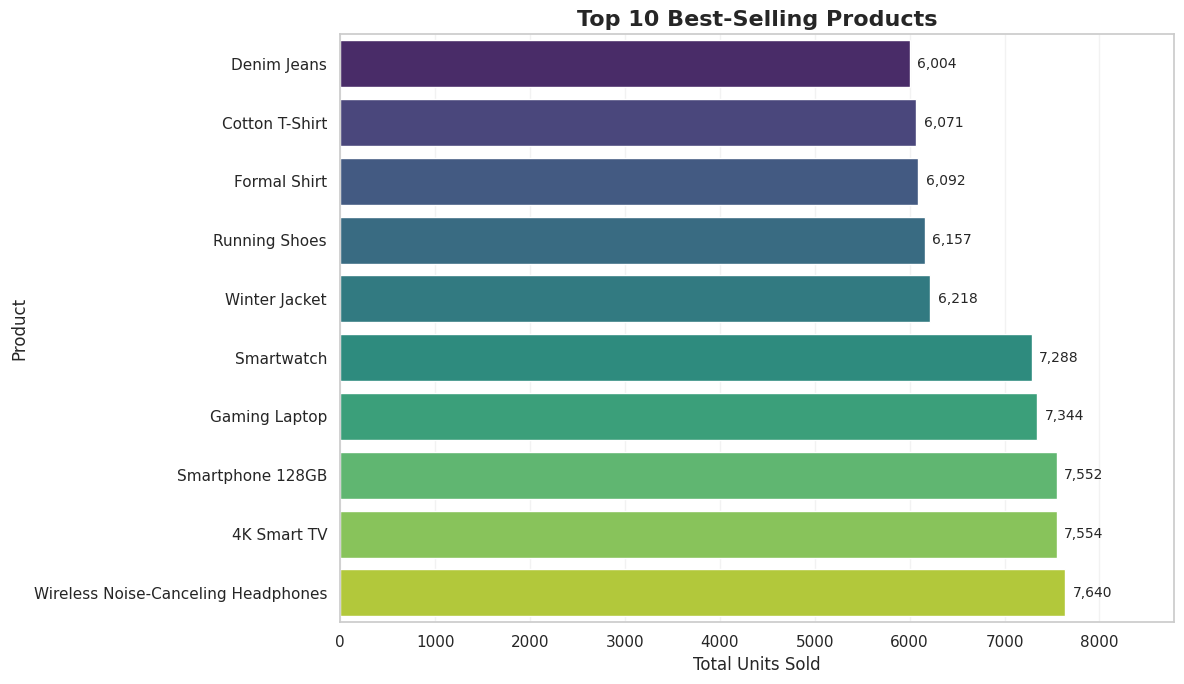

In [23]:
# Sort for a readable horizontal chart
top_10_products_plot = top_10_products.sort_values(
    "Units_Sold",
    ascending=True
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_10_products_plot,
    x="Units_Sold",
    y="Product_Name",
    hue="Product_Name",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Best-Selling Products",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Total Units Sold")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.25)

maximum_units = top_10_products_plot["Units_Sold"].max()

for bar in ax.patches:
    units = bar.get_width()

    ax.text(
        units + maximum_units * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(units):,}",
        va="center",
        fontsize=10
    )

plt.xlim(0, maximum_units * 1.15)
plt.tight_layout()

plt.savefig(
    "/content/outputs/top_10_best_selling_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

#Wireless Noise-Canceling Headphones** were the best-selling product, with 7,640 units sold. They were closely followed by the 4K Smart TV (7,554 units) and Smartphone 128GB (7,552 units). The small difference between the leading products indicates that demand is distributed across several products rather than dominated by one item.

#The five highest-selling products are all electronics, demonstrating particularly strong customer demand for technology products. The retailer should maintain sufficient inventory for these products and consider bundled offers or targeted promotions to increase related sales.

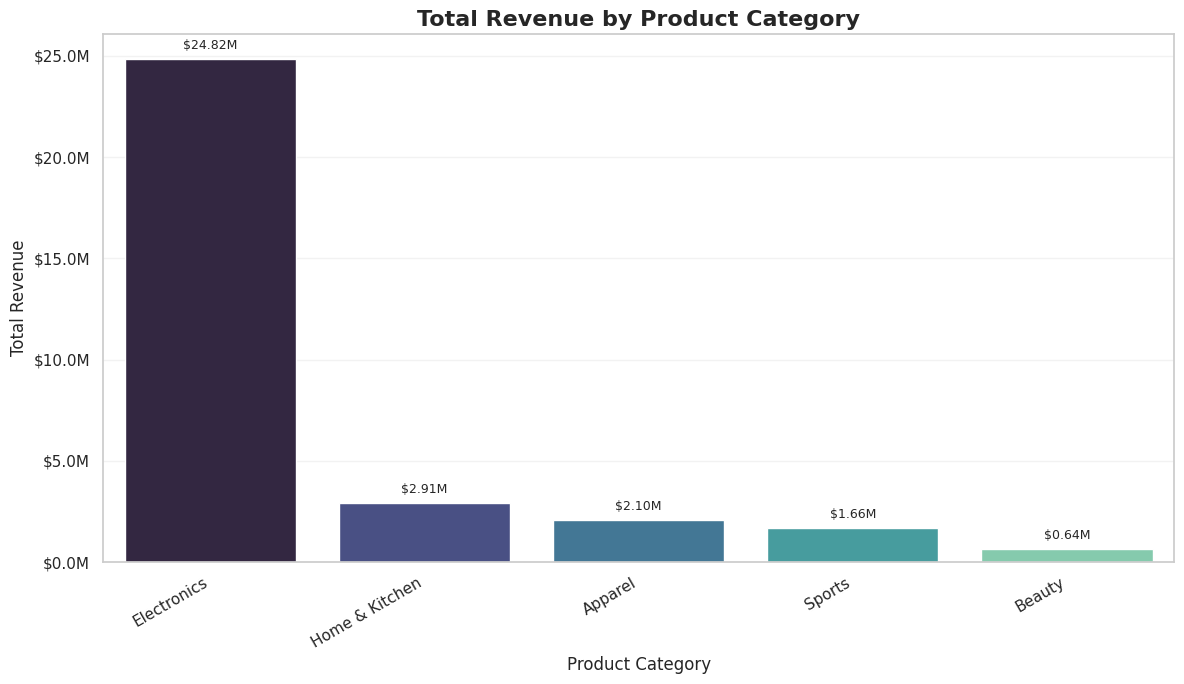

In [24]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=category_performance,
    x="Product_Category",
    y="Total_Revenue",
    hue="Product_Category",
    order=category_performance["Product_Category"],
    palette="mako",
    legend=False
)

plt.title(
    "Total Revenue by Product Category",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)

ax.yaxis.set_major_formatter(millions_formatter)

revenue_offset = category_performance["Total_Revenue"].max() * 0.02

for position, row in category_performance.reset_index(drop=True).iterrows():
    ax.text(
        position,
        row["Total_Revenue"] + revenue_offset,
        f"${row['Total_Revenue'] / 1_000_000:.2f}M",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "/content/outputs/revenue_by_product_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

**Electronics** generated approximately **\$24.82 million**, far exceeding **Home & Kitchen at \$2.91 million**, **Apparel at \$2.10 million**, **Sports at \$1.66 million**, and **Beauty at \$0.64 million**. Electronics therefore contributed approximately **77% of total revenue**, confirming that technology products are the retailer’s main revenue driver.

The business should prioritize electronics inventory and supplier reliability. However, this high concentration also creates dependency risk, so the retailer should investigate opportunities to improve weaker categories through pricing reviews, product bundles, and targeted promotions.

## 6. Correlation Analysis

# A Pearson correlation heatmap is used to examine the strength and direction of linear relationships between numerical variables. Correlation values range from -1 to +1.

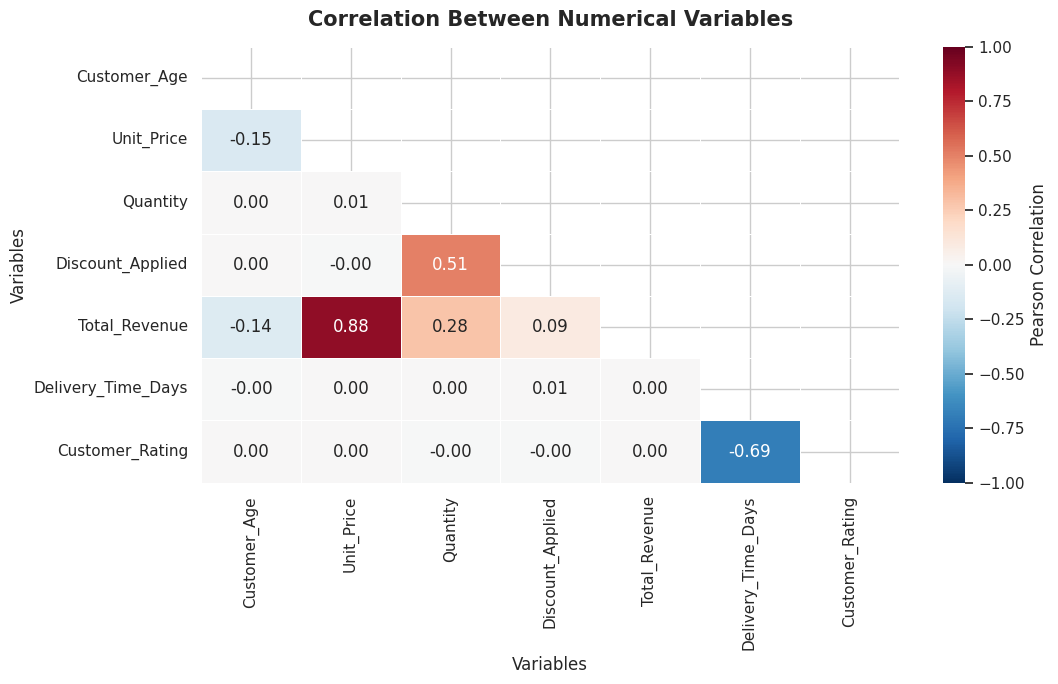

Five strongest numerical relationships:

Unit_Price ↔ Total_Revenue: 0.883
Delivery_Time_Days ↔ Customer_Rating: -0.688
Quantity ↔ Discount_Applied: 0.506
Quantity ↔ Total_Revenue: 0.283
Customer_Age ↔ Unit_Price: -0.155


In [25]:
# Select meaningful numerical variables
correlation_columns = [
    "Customer_Age",
    "Unit_Price",
    "Quantity",
    "Discount_Applied",
    "Total_Revenue",
    "Delivery_Time_Days",
    "Customer_Rating"
]

# Calculate Pearson correlations
correlation_matrix = df[correlation_columns].corr(method="pearson")

# Display the lower half only to avoid repeating identical relationships
mask = np.triu(
    np.ones_like(correlation_matrix, dtype=bool)
)

plt.figure(figsize=(11, 7))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title(
    "Correlation Between Numerical Variables",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()

plt.savefig(
    "/content/outputs/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Identify the five strongest relationships
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

strongest_correlations = (
    upper_triangle
    .stack()
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .head(5)
)

print("Five strongest numerical relationships:\n")

for (variable_1, variable_2), correlation in strongest_correlations.items():
    print(f"{variable_1} ↔ {variable_2}: {correlation:.3f}")

### Observation

#The strongest positive relationship is between **Unit Price and Total Revenue (r = 0.883)**, indicating that higher-priced products are the main contributors to revenue. This relationship is expected because unit price is used in calculating transaction revenue.

#A strong negative relationship exists between **Delivery Time and Customer Rating (r = -0.688)**, suggesting that customer satisfaction decreases substantially as delivery time increases. Quantity and Discount Applied also have a moderate positive relationship **(r = 0.506)**, which may indicate that larger purchases receive higher discounts. These correlations reveal important patterns, but they represent associations and do not alone prove causation.

## 7. Delivery Time and Customer Satisfaction

#This analysis investigates whether longer delivery times are associated with lower customer ratings. Average ratings are calculated for each delivery-time value and compared with the overall customer rating.

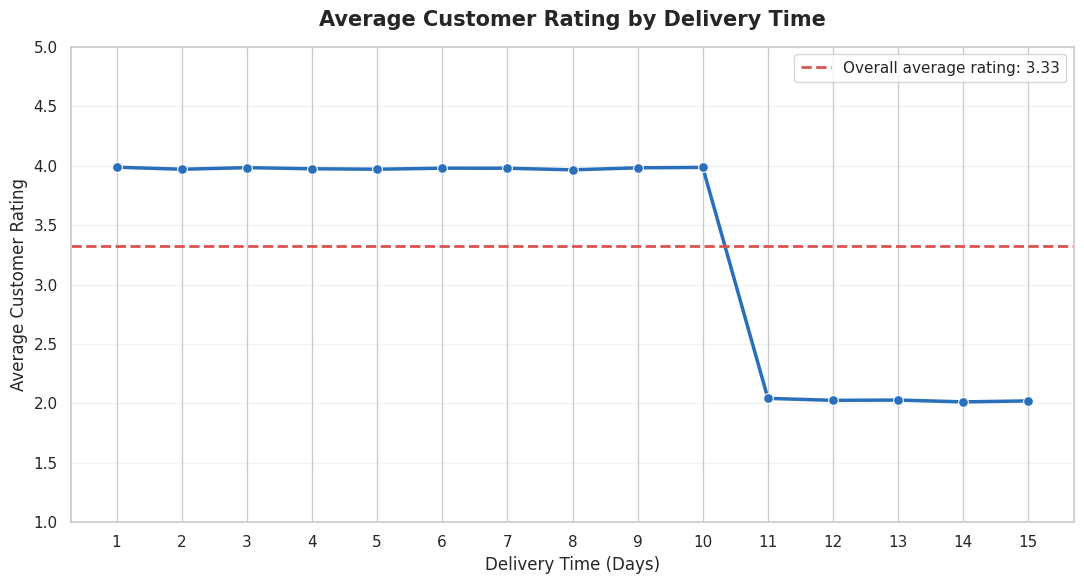

Spearman correlation: -0.652
Highest average rating: 3.99 for 1-day delivery
Lowest average rating: 2.01 for 14-day delivery


In [26]:
# Calculate rating statistics for each delivery time
delivery_rating_analysis = (
    df.groupby("Delivery_Time_Days", as_index=False)
    .agg(
        Average_Rating=("Customer_Rating", "mean"),
        Median_Rating=("Customer_Rating", "median"),
        Transaction_Count=("Transaction_ID", "nunique")
    )
    .sort_values("Delivery_Time_Days")
)

overall_average_rating = df["Customer_Rating"].mean()

# Spearman correlation is suitable for examining an ordered relationship
delivery_rating_correlation = df[
    ["Delivery_Time_Days", "Customer_Rating"]
].corr(method="spearman").iloc[0, 1]

# Create the visualization
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=delivery_rating_analysis,
    x="Delivery_Time_Days",
    y="Average_Rating",
    marker="o",
    linewidth=2.5,
    markersize=7,
    color="#2A6FBB"
)

plt.axhline(
    overall_average_rating,
    color="#D9534F",
    linestyle="--",
    linewidth=2,
    label=f"Overall average rating: {overall_average_rating:.2f}"
)

plt.title(
    "Average Customer Rating by Delivery Time",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Average Customer Rating")
plt.xticks(delivery_rating_analysis["Delivery_Time_Days"])
plt.ylim(1, 5)
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

plt.savefig(
    "/content/outputs/delivery_time_vs_customer_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Summarize the most important results
highest_rating_row = delivery_rating_analysis.loc[
    delivery_rating_analysis["Average_Rating"].idxmax()
]

lowest_rating_row = delivery_rating_analysis.loc[
    delivery_rating_analysis["Average_Rating"].idxmin()
]

print(f"Spearman correlation: {delivery_rating_correlation:.3f}")
print(
    f"Highest average rating: {highest_rating_row['Average_Rating']:.2f} "
    f"for {int(highest_rating_row['Delivery_Time_Days'])}-day delivery"
)
print(
    f"Lowest average rating: {lowest_rating_row['Average_Rating']:.2f} "
    f"for {int(lowest_rating_row['Delivery_Time_Days'])}-day delivery"
)

### Observation

Delivery time has a strong negative relationship with customer satisfaction, with a **Spearman correlation of -0.652**. Average ratings remain close to **4.0** for deliveries completed within **1–10 days**, but fall sharply to approximately **2.0** when delivery takes **11 days or longer**.

One-day delivery achieved the highest average rating at **3.99**, while 14-day delivery produced the lowest at **2.01**. This reveals an important **10-day service threshold**: the retailer should prioritize keeping delivery times at 10 days or less and investigate the operational causes of longer shipments.

## Conclusion and Business Recommendations

The exploratory analysis identified clear patterns in sales seasonality, customer demographics, product performance, and customer satisfaction. Revenue is strongly concentrated in electronics, customers aged 25–44 represent the main audience, and delivery times longer than 10 days are associated with a sharp decline in customer ratings.

### Actionable Recommendations

1. **Prepare early for fourth-quarter demand.**  
   Revenue consistently peaks near the end of each year, with November 2025 generating the highest monthly revenue and 2025 Q4 producing approximately $4.99 million. Inventory and marketing campaigns should be prepared before October, especially for the best-selling electronics.

2. **Keep delivery times within 10 days.**  
   Average customer ratings remain close to 4.0 for deliveries completed within 1–10 days but fall to approximately 2.0 after 10 days. The retailer should establish a maximum 10-day delivery target, flag orders approaching eight days, and investigate delayed carriers or locations.

3. **Protect the electronics revenue stream.**  
   Electronics generate approximately 77% of total revenue, while wireless noise-canceling headphones, 4K smart TVs, and smartphones are among the best-selling products. The retailer should maintain safety stock, monitor product availability, and develop reliable relationships with multiple electronics suppliers.

4. **Reduce dependence on one product category.**  
   Although electronics are highly profitable, excessive revenue concentration creates business risk. The retailer should test bundles, promotions, and pricing strategies in Home & Kitchen, Apparel, Sports, and Beauty to identify opportunities for category growth.

5. **Target the core customer segment with inclusive campaigns.**  
   Customers aged 25–44 account for 68.6% of the customer base. Marketing campaigns should prioritize the interests and purchasing behaviour of this age range. Since female and male customers are almost equally represented, advertising should remain gender-inclusive and use purchasing behaviour for deeper personalization.

6. **Evaluate quantity-based discount strategies.**  
   Quantity and discount applied have a moderate positive correlation of 0.506. The retailer should test structured bulk-purchase discounts while monitoring profit margins, revenue per transaction, and whether discounts generate genuinely higher sales rather than unnecessary price reductions.

### Analysis Limitations

The final month and quarter of 2026 appear to contain incomplete data, so their low revenue totals should not be interpreted as a confirmed decline. In addition, correlation identifies relationships between variables but does not prove that one variable directly causes another.